# Analysis of application data columns
- table: application_test.csv <br>
- This table contains static data for all applications (1 application per row)
---

## 0. Import libraries

In [8]:
pwd

'c:\\Users\\alekk\\Desktop\\Data Analytics & Programming\\home_credit_default_risk\\notebooks'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import plot_quantitative_distribution

## 1. Get the data

In [10]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Review the columns
Since we have 122 columns it will be necessary to discard some (e.g. technical columns)

__Loan info__:
- `SK_ID_CURR` - ID of loan in our sample
- `TARGET` - Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)
- `NAME_CONTRACT_TYPE` - Identification if loan is cash or revolving
- `AMT_CREDIT` - Credit amount of the loan
- `AMT_ANNUITY` - Loan annuity
- `AMT_GOODS_PRICE` - For consumer loans it is the price of the goods for which the loan is given

In [11]:
type_of_cols_in_app = []
all_cols = []
loan_cols = ['SK_ID_CURR','TARGET', 'NAME_CONTRACT_TYPE','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']
# print([col for col in loan_cols if col not in app_df.columns])
all_cols += loan_cols
type_of_cols_in_app.append(loan_cols)
print(f"Number of loan columns: {len(loan_cols)}")

Number of loan columns: 6


__Application info__:
- `NAME_TYPE_SUITE` - Who was accompanying client when he was applying for the loan
- `DAYS_ID_PUBLISH` - How many days before the application did client change the identity document with which he applied for the loan, time only
- `DAYS_EMPLOYED` - How many days before the application the person started current employment,time only relative to the application
- `DAYS_REGISTRATION` - How many days before the application did client change his registration ,time only relative to the 
application
- `DAYS_LAST_PHONE_CHANGE` - How many days before application did client change phone
- `WEEKDAY_APPR_PROCESS_START` On which day of the week did the client apply for the loan
- `HOUR_APPR_PROCESS_START` - Approximately at what hour did the client apply for the loan, rounded
- `FLAG_MOBIL` - Did client provide mobile phone (1=YES, 0=NO)
- `FLAG_EMP_PHONE` - Did client provide work phone (1=YES, 0=NO)
- `FLAG_WORK_PHONE` - Did client provide home phone (1=YES, 0=NO)
- `FLAG_CONT_MOBILE` - Was mobile phone reachable (1=YES, 0=NO)
- `FLAG_PHONE` - Did client provide home phone (1=YES, 0=NO) (Possible duplicate with FLAG_WORK_PHONE)
- `FLAG_EMAIL` - Did client provide email (1=YES, 0=NO)

In [12]:
application_cols = [
    'NAME_TYPE_SUITE','DAYS_ID_PUBLISH','DAYS_EMPLOYED','DAYS_REGISTRATION',
    'DAYS_LAST_PHONE_CHANGE','WEEKDAY_APPR_PROCESS_START','HOUR_APPR_PROCESS_START',
    'FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE','FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL'
]
# print([col for col in application_cols if col not in app_df.columns])
all_cols += application_cols
type_of_cols_in_app.append(application_cols)
print(f"Number of application columns: {len(application_cols)}")

Number of application columns: 13


Document provided by client:
- `FLAG_DOCUMENT_2` - Did client provide document 2
- `FLAG_DOCUMENT_3` - Did client provide document 3
- `FLAG_DOCUMENT_4` - Did client provide document 4
- `FLAG_DOCUMENT_5` - Did client provide document 5
- `FLAG_DOCUMENT_6`  - Did client provide document 6
- `FLAG_DOCUMENT_7`  - Did client provide document 7
- `FLAG_DOCUMENT_8` - Did client provide document 8
- `FLAG_DOCUMENT_9` - Did client provide document 9
- `FLAG_DOCUMENT_10` - Did client provide document 10
- `FLAG_DOCUMENT_11` - Did client provide document 11
- `FLAG_DOCUMENT_12` - Did client provide document 12
- `FLAG_DOCUMENT_13` - Did client provide document 13
- `FLAG_DOCUMENT_14` - Did client provide document 14
- `FLAG_DOCUMENT_15` - Did client provide document 15
- `FLAG_DOCUMENT_16` - Did client provide document 16
- `FLAG_DOCUMENT_17` - Did client provide document 17
- `FLAG_DOCUMENT_18` - Did client provide document 18
- `FLAG_DOCUMENT_19` - Did client provide document 19
- `FLAG_DOCUMENT_20` - Did client provide document 20
- `FLAG_DOCUMENT_21` - Did client provide document 21

In [13]:
document_provided_cols = [
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
]
# print([col for col in document_provided_cols if col not in app_df.columns])
all_cols += document_provided_cols
type_of_cols_in_app.append(document_provided_cols)
print(f"Document provided columns: {len(document_provided_cols)}")

Document provided columns: 20


__Credit bureau info__:
- `AMT_REQ_CREDIT_BUREAU_HOUR` - Number of enquiries to Credit Bureau about the client one hour before application
- `AMT_REQ_CREDIT_BUREAU_DAY` - Number of enquiries to Credit Bureau about the client one day before application (excluding one hour before application)
- `AMT_REQ_CREDIT_BUREAU_WEEK` - Number of enquiries to Credit Bureau about the client one week before application (excluding one day before application)
- `AMT_REQ_CREDIT_BUREAU_MON` - Number of enquiries to Credit Bureau about the client one month before application (excluding one week before application)
- `AMT_REQ_CREDIT_BUREAU_QRT` - Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application)
- `AMT_REQ_CREDIT_BUREAU_YEAR` - Number of enquiries to Credit Bureau about the client one day year (excluding last 3 months before application)

In [14]:
credit_bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
# print([col for col in credit_bureau_cols if col not in app_df.columns])
all_cols += credit_bureau_cols
type_of_cols_in_app.append(credit_bureau_cols)
print(f"Credit bureau columns: {len(credit_bureau_cols)}")

Credit bureau columns: 6


__Clinet's material and financial info__:
- `FLAG_OWN_CAR` - Flag if the client owns a car (possible NMAR - not missing at random)
- `FLAG_OWN_REALTY` - Flag if client owns a house or flat (possible NMAR)
- `AMT_INCOME_TOTAL` - Income of the client
- `NAME_INCOME_TYPE` - Clients income type (businessman, working, maternity leave,…)
- `NAME_HOUSING_TYPE` - What is the housing situation of the client (renting, living with parents, ...)
- `OWN_CAR_AGE` - Age of client's car

In [15]:
material_financial_cols = [
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 
    'NAME_INCOME_TYPE', 'NAME_HOUSING_TYPE', 'OWN_CAR_AGE' 
]
# print([col for col in material_financial_cols if col not in app_df.columns])
all_cols += material_financial_cols
type_of_cols_in_app.append(material_financial_cols)
print(f"Material and financial columns: {len(material_financial_cols)}")

Material and financial columns: 6


__Client's demografic and family info__:
- `CODE_GENDER` - Gender of the client
- `DAYS_BIRTH` - Client's age in days at the time of application,time only relative to the application
- `CNT_CHILDREN` - Number of children the client has (useful for calculating income/people in household)
- `CNT_FAM_MEMBERS` - How many family members does client have
- `NAME_FAMILY_STATUS` - Family status of the client
- `NAME_EDUCATION_TYPE` - Level of highest education the client achieved
- `OCCUPATION_TYPE` - What kind of occupation does the client have
- `ORGANIZATION_TYPE` - Type of organization where client works
- `REG_REGION_NOT_LIVE_REGION` - Flag if client's permanent address does not match contact address (1=different, 0=same, at region level)
- `REG_REGION_NOT_WORK_REGION` - Flag if client's permanent address does not match work address (1=different, 0=same, at region level)
- `LIVE_REGION_NOT_WORK_REGION` - Flag if client's contact address does not match work address (1=different, 0=same, at region level)
- `REG_CITY_NOT_LIVE_CITY` - Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)
- `REG_CITY_NOT_WORK_CITY` - Flag if client's permanent address does not match work address (1=different, 0=same, at city level)
- `LIVE_CITY_NOT_WORK_CITY` - Flag if client's contact address does not match work address (1=different, 0=same, at city level)

In [16]:
demografic_family_cols = [
    'CODE_GENDER', 'DAYS_BIRTH', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 
    'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 
    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 
    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]
# print([col for col in demografic_family_cols if col not in app_df.columns])
all_cols += demografic_family_cols
type_of_cols_in_app.append(demografic_family_cols)
print(f"Demografic and family columns: {len(demografic_family_cols)}")

Demografic and family columns: 14


__Client's exteral raitings__:
- `EXT_SOURCE_1` - Normalized score from external data source,normalized
- `EXT_SOURCE_2` - Normalized score from external data source,normalized
- `EXT_SOURCE_3` - Normalized score from external data source,normalized

In [17]:
extarnal_raiting_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
# print([col for col in extarnal_raiting_cols if col not in app_df.columns])
all_cols += extarnal_raiting_cols
type_of_cols_in_app.append(extarnal_raiting_cols)
print(f"Exteran raitings columns: {len(extarnal_raiting_cols)}")

Exteran raitings columns: 3


__Social surrouding of the client__:
- `OBS_30_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings with observable 30 DPD (days past due) default
- `DEF_30_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings defaulted on 30 DPD (days past due)
- `OBS_60_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings with observable 60 DPD (days past due) default
- `DEF_60_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings defaulted on 60 (days past due) DPD

In [18]:
social_surrounding_cols = [
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'
]
# print([col for col in social_surrounding_cols if col not in app_df.columns])
all_cols += social_surrounding_cols
type_of_cols_in_app.append(social_surrounding_cols)
print(f"Social surrounding columns: {len(social_surrounding_cols)}")

Social surrounding columns: 4


__Region when client lives info__:
- `REGION_POPULATION_RELATIVE` - Normalized population of region where client lives (higher number means the client lives in more populated)
- `REGION_RATING_CLIENT` - Our rating of the region where client lives (1,2,3)
- `REGION_RATING_CLIENT_W_CITY` Our rating of the region where client lives with taking city into account (1,2,3)

In [19]:
region_cols = ['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
# print([col for col in region_cols if col not in app_df.columns])
all_cols += region_cols
type_of_cols_in_app.append(region_cols)
print(f"Region columns: {len(region_cols)}")

Region columns: 3


__Building where client lives info__:
- `APARTMENTS_AVG` - Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor, normalized
- `BASEMENTAREA_AVG` - What is average basement area, normalized
- `YEARS_BEGINEXPLUATATION_AVG` - What is average years beiginexpluatation, normalized
- `YEARS_BUILD_AVG` - What is average years buld, normalized
- `COMMONAREA_AVG` - What is average commonarea, normalized
- `ELEVATORS_AVG` - What is average number of elevators, normalized
- `ENTRANCES_AVG` - What is average number of entrances, normalized
- `FLOORSMAX_AVG` - What is average floorsmax, normalized
- `FLOORSMIN_AVG` - What is average floorsmin, normalized
- `LANDAREA_AVG` - What is average landarea, normalized
- `LIVINGAPARTMENTS_AVG` - What is average number of living apaprtments, normalized
- `LIVINGAREA_AVG` - What is average living area, normalized
- `NONLIVINGAPARTMENTS_AVG` - What is average number of non-living apartments, normalized
- `NONLIVINGAREA_AVG` - What is average non-living area, normalized
---
- `APARTMENTS_MODE` - What is modus of number of apartments, normalized
- `BASEMENTAREA_MODE` - What is modus of basement area, normalized
- `YEARS_BEGINEXPLUATATION_MODE` - What is modus of years beginexpluatation, normalized
- `YEARS_BUILD_MODE` - What is modus of years build, normalized
- `COMMONAREA_MODE` - What is modus of commonarea, normalized
- `ELEVATORS_MODE` - What is modus of elevators, normalized
- `ENTRANCES_MODE` What is modus of entrances, normalized
- `FLOORSMAX_MODE` - What is modus of floorsmax, normalized
- `FLOORSMIN_MODE` - What is modus of floorsmin, normalized
- `LANDAREA_MODE` - What is modus of landarea, normalized
- `LIVINGAPARTMENTS_MODE` - What is modus of living aprartments, normalized
- `LIVINGAREA_MODE` - What is modus of livingarea, normalized
- `NONLIVINGAPARTMENTS_MODE` - What is modus of non-living apartments, normalized
- `NONLIVINGAREA_MODE` - What is modus of non-living area, normalized
---
- `APARTMENTS_MEDI` - What is median of number of apartments, normalized
- `BASEMENTAREA_MEDI` - What is median of basement area, normalized
- `YEARS_BEGINEXPLUATATION_MEDI` - What is median of years beginexpluatation, normalized
- `YEARS_BUILD_MEDI` - What is median of age of building, normalized
- `COMMONAREA_MEDI` - What is median of common area, normalized
- `ELEVATORS_MEDI` - What is median of number of elevators, normalized
- `ENTRANCES_MEDI` - What is median of number of entrances, normalized
- `FLOORSMAX_MEDI` - What is median of floorsmax, normalized
- `FLOORSMIN_MEDI` - What is median of floormin, normalized
- `LANDAREA_MEDI` - What is median of landarea, normalized
- `LIVINGAPARTMENTS_MEDI` - What is median of number of living appartemnts, normalized
- `LIVINGAREA_MEDI` - What is median of living area, normalized
- `NONLIVINGAPARTMENTS_MEDI` - What is median of non-living appartments, normalized
- `NONLIVINGAREA_MEDI` - What is median of non-living area, normalized
---
- `FONDKAPREMONT_MODE` - What is the modus of fondkapremont, normalized
- `HOUSETYPE_MODE` - What is the modus of house type, normalized
- `TOTALAREA_MODE` - What is the modus of total area, normalized
- `WALLSMATERIAL_MODE` - What is the modus of walls material, normalized
- `EMERGENCYSTATE_MODE` - What is the modus of emergencystate, normalized

In [20]:
building_cols = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
    'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 

    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
    'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',

    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI',
    'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI',

    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]

all_cols += building_cols

building_avg_cols = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
    'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG'
]
type_of_cols_in_app.append(building_avg_cols)

building_mode_cols = [
    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
    'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]
type_of_cols_in_app.append(building_mode_cols)

building_medi_cols = [
    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI',
    'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI'
]
type_of_cols_in_app.append(building_medi_cols)

# print([col for col in building_cols if col not in app_df.columns])

print(f"Building columns: {len(building_cols)}")
print(f"Building avg columns: {len(building_avg_cols)}")
print(f"Building mode columns: {len(building_mode_cols)}")
print(f"Building medi columns: {len(building_medi_cols)}")

Building columns: 47
Building avg columns: 14
Building mode columns: 19
Building medi columns: 14


Probably most of the columns regarding region where client lives and building type want be efficient predictors. <br>
Financial info, demographic info, and exteral raitings might be crucial preditors. <br> 

In order to say if any column will be a good preditor we have to make sure that this column does not contain to many NANs

## 3. Sum of missing values in columns

In [21]:
print(len(type_of_cols_in_app))

12


In [22]:
app_n = app_df.shape[0]
print('------------------------')
for cols in type_of_cols_in_app:
    print(app_df[cols].isna().sum() / app_n)
    print('------------------------')

------------------------
SK_ID_CURR            0.000000
TARGET                0.000000
NAME_CONTRACT_TYPE    0.000000
AMT_CREDIT            0.000000
AMT_ANNUITY           0.000039
AMT_GOODS_PRICE       0.000904
dtype: float64
------------------------
NAME_TYPE_SUITE               0.004201
DAYS_ID_PUBLISH               0.000000
DAYS_EMPLOYED                 0.000000
DAYS_REGISTRATION             0.000000
DAYS_LAST_PHONE_CHANGE        0.000003
WEEKDAY_APPR_PROCESS_START    0.000000
HOUR_APPR_PROCESS_START       0.000000
FLAG_MOBIL                    0.000000
FLAG_EMP_PHONE                0.000000
FLAG_WORK_PHONE               0.000000
FLAG_CONT_MOBILE              0.000000
FLAG_PHONE                    0.000000
FLAG_EMAIL                    0.000000
dtype: float64
------------------------
FLAG_DOCUMENT_2     0.0
FLAG_DOCUMENT_3     0.0
FLAG_DOCUMENT_4     0.0
FLAG_DOCUMENT_5     0.0
FLAG_DOCUMENT_6     0.0
FLAG_DOCUMENT_7     0.0
FLAG_DOCUMENT_8     0.0
FLAG_DOCUMENT_9     0.0
FLAG_DOCUM

FLAG_OWN_CAR         0.000000
FLAG_OWN_REALTY      0.000000
AMT_INCOME_TOTAL     0.000000
NAME_INCOME_TYPE     0.000000
NAME_HOUSING_TYPE    0.000000
OWN_CAR_AGE          0.659908
dtype: float64
------------------------
CODE_GENDER                    0.000000
DAYS_BIRTH                     0.000000
CNT_CHILDREN                   0.000000
CNT_FAM_MEMBERS                0.000007
NAME_FAMILY_STATUS             0.000000
NAME_EDUCATION_TYPE            0.000000
OCCUPATION_TYPE                0.313455
ORGANIZATION_TYPE              0.000000
REG_REGION_NOT_LIVE_REGION     0.000000
REG_REGION_NOT_WORK_REGION     0.000000
LIVE_REGION_NOT_WORK_REGION    0.000000
REG_CITY_NOT_LIVE_CITY         0.000000
REG_CITY_NOT_WORK_CITY         0.000000
LIVE_CITY_NOT_WORK_CITY        0.000000
dtype: float64
------------------------
EXT_SOURCE_1    0.563811
EXT_SOURCE_2    0.002146
EXT_SOURCE_3    0.198253
dtype: float64
------------------------
OBS_30_CNT_SOCIAL_CIRCLE    0.00332
DEF_30_CNT_SOCIAL_CIRCLE    0

Most of the columns have small number of NANs (less than 1%)

Exceptions are:
- `OWN_CAR_AGE` - 66% (Possible NMAR --> creating flag variable)
- `OCUPATION_TYPE` - 31% (Possible NMAR --> creating flag variable)
- `EXT_SOURCE_1` - 65% (Not suitable for imputation)
- `EXT_SOURCE_3` - 20% (Not safe for imputation)
- `all credit bureau columns` - 13.5% (Can be imputed)
- `all building type columns` - 48-70% (Not suitable for imputation) 

## 4. Dropping colums with high number of NANs

In [23]:
app_df_1 = app_df.copy()
cols_to_drop = ['EXT_SOURCE_1', 'EXT_SOURCE_3'] + building_cols
cols_to_keep = [col for col in app_df.columns if col not in cols_to_drop]


print(f"Number of all columns: {app_df.shape[1]}")
print(f"Len of cols_to_drop: {len(cols_to_drop)}")
print(f"Len of cols_to_keep: {len(cols_to_keep)}")

app_df_1 = app_df_1.drop(columns=cols_to_drop)
print(f"New number of columns: {app_df_1.shape[1]}")


Number of all columns: 122
Len of cols_to_drop: 49
Len of cols_to_keep: 73
New number of columns: 73


## 5. Filling up missing values and creating flag variables

### 5.1 OWN_CAR_AGE

In [24]:
app_df_1['OWN_CAR_AGE_MISSING'] = np.where(app_df_1['OWN_CAR_AGE'].isna(), 1, 0)
print(app_df_1['OWN_CAR_AGE_MISSING'].value_counts())

OWN_CAR_AGE_MISSING
1    202929
0    104582
Name: count, dtype: int64


In [25]:
app_df_1['OCCUPATION_TYPE_MISSING'] = np.where(app_df_1['OCCUPATION_TYPE'].isna(), 1, 0)
print(app_df_1['OCCUPATION_TYPE_MISSING'].value_counts())

OCCUPATION_TYPE_MISSING
0    211120
1     96391
Name: count, dtype: int64


In [26]:
app_df_1[app_df_1['AMT_REQ_CREDIT_BUREAU_HOUR'].isna()].head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING,OCCUPATION_TYPE_MISSING
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0
14,100018,0,Cash loans,F,N,Y,0,189000.0,773680.5,32778.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0
17,100021,0,Revolving loans,F,N,Y,1,81000.0,270000.0,13500.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0
20,100024,0,Revolving loans,M,Y,Y,0,135000.0,427500.0,21375.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [27]:
((
    app_df_1['AMT_REQ_CREDIT_BUREAU_HOUR'].isna() &
    app_df_1['AMT_REQ_CREDIT_BUREAU_DAY'].isna() &
    app_df_1['AMT_REQ_CREDIT_BUREAU_WEEK'].isna() &
    app_df_1['AMT_REQ_CREDIT_BUREAU_MON'].isna() &
    app_df_1['AMT_REQ_CREDIT_BUREAU_QRT'].isna() &
    app_df_1['AMT_REQ_CREDIT_BUREAU_YEAR'].isna()
).sum()/app_n).round(6)

np.float64(0.135016)

13.5% of clients have NANs in all `AMT_REQ_CREDIT_BUREAU` columns

In [28]:
# Creating missing bureau flag
app_df_1['AMT_REQ_CREDIT_BUREAU_MISSING'] = np.where(
    app_df_1['AMT_REQ_CREDIT_BUREAU_HOUR'].isna(),
    1, 0
)

Checking the distribution of `AMT_REQ_CREDIT_BUREAU` variables without missing values

In [37]:
app_df_2 = app_df_1.copy()
app_df_2 = app_df_2.loc[app_df_2['AMT_REQ_CREDIT_BUREAU_MISSING']==0]
app_df_2.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING,OCCUPATION_TYPE_MISSING,AMT_REQ_CREDIT_BUREAU_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0.0,0.0,0.0,0.0,1.0,1.0,1,0,0


In [40]:
app_df_2[credit_bureau_cols].describe()

,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [41]:
app_df_2[app_df_2['AMT_REQ_CREDIT_BUREAU_QRT']==261.000000]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING,OCCUPATION_TYPE_MISSING,AMT_REQ_CREDIT_BUREAU_MISSING
239474,377322,0,Cash loans,F,N,Y,1,360000.0,1035000.0,30393.0,...,0,0.0,0.0,0.0,1.0,261.0,0.0,1,0,0


Some observations have invalid values for `AMT_REQ_CREDIT_BUREAU`. For example AMT_REQ_CREDIT_BUREAU_QRT is greater thah AMT_REQ_CREDIT_BUREAU_YEAR which doesn't make sense.

In [49]:
app_df_3 = app_df_2.copy()
app_df_3 = app_df_3.loc[
    (app_df_3['AMT_REQ_CREDIT_BUREAU_HOUR'] <= app_df_3['AMT_REQ_CREDIT_BUREAU_DAY']) &
    (app_df_3['AMT_REQ_CREDIT_BUREAU_DAY'] <= app_df_3['AMT_REQ_CREDIT_BUREAU_WEEK']) &
    (app_df_3['AMT_REQ_CREDIT_BUREAU_WEEK'] <= app_df_3['AMT_REQ_CREDIT_BUREAU_MON']) &
    (app_df_3['AMT_REQ_CREDIT_BUREAU_MON'] <= app_df_3['AMT_REQ_CREDIT_BUREAU_QRT']) &
    (app_df_3['AMT_REQ_CREDIT_BUREAU_QRT'] <= app_df_3['AMT_REQ_CREDIT_BUREAU_YEAR'])
]

print(f"Number of all observations: {app_df_2.shape[0]}")
print(f"Number of observations with valied AMT_REQ_CREDIT_BUREAU values: {app_df_3.shape[0]}")
print(f"Number of obs with invalid values: {app_df_2.shape[0] - app_df_3.shape[0]}, {(app_df_2.shape[0] - app_df_3.shape[0]) / app_df_2.shape[0]}")

Number of all observations: 265992
Number of observations with valied AMT_REQ_CREDIT_BUREAU values: 204543
Number of obs with invalid values: 61449, 0.23101822611206352


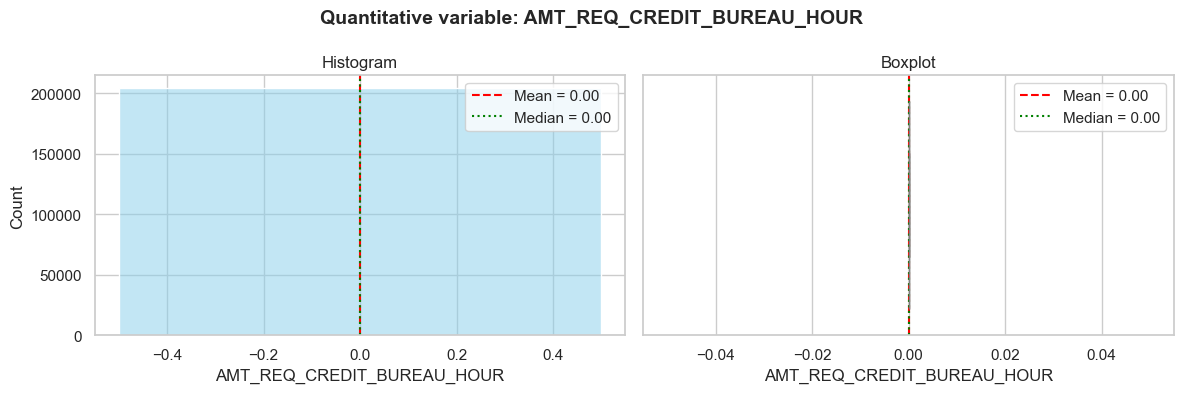

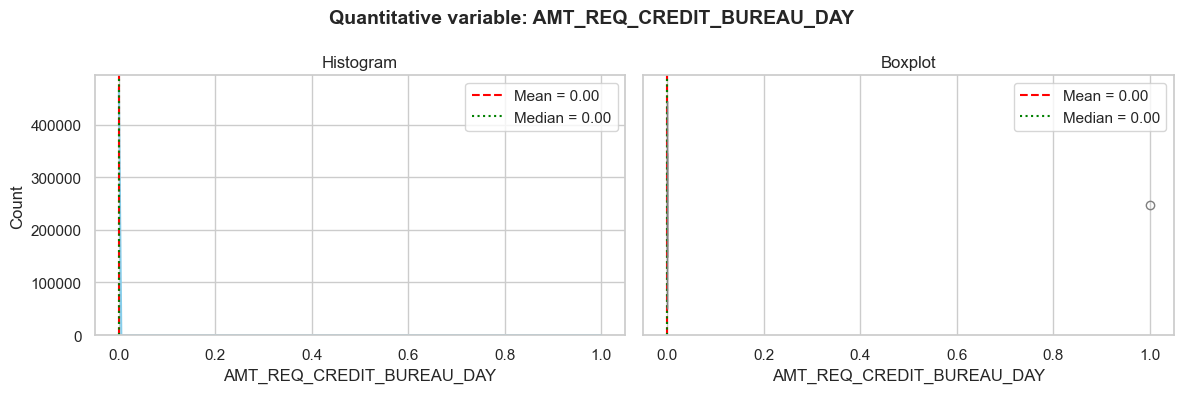

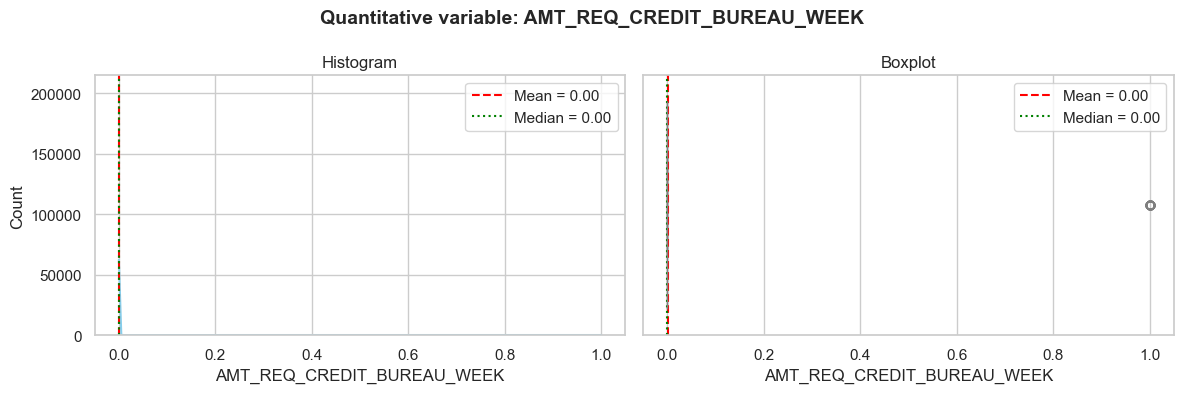

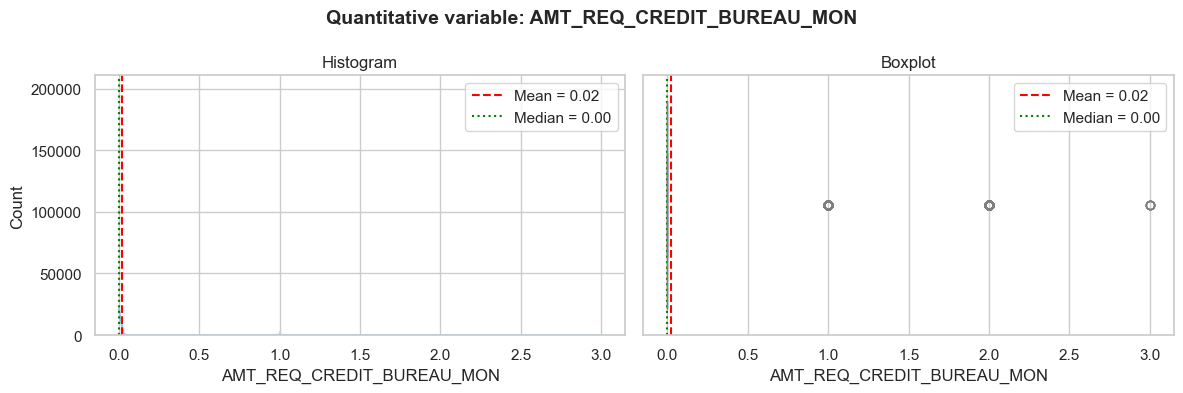

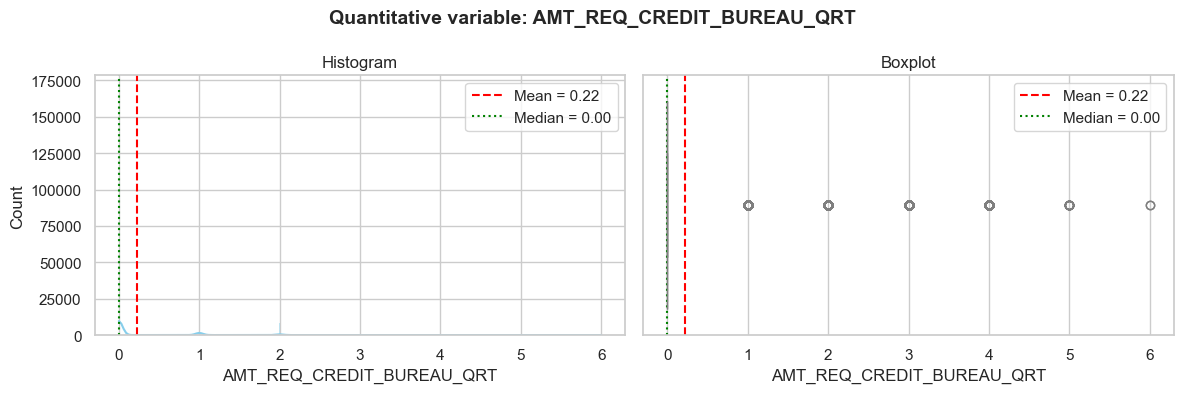

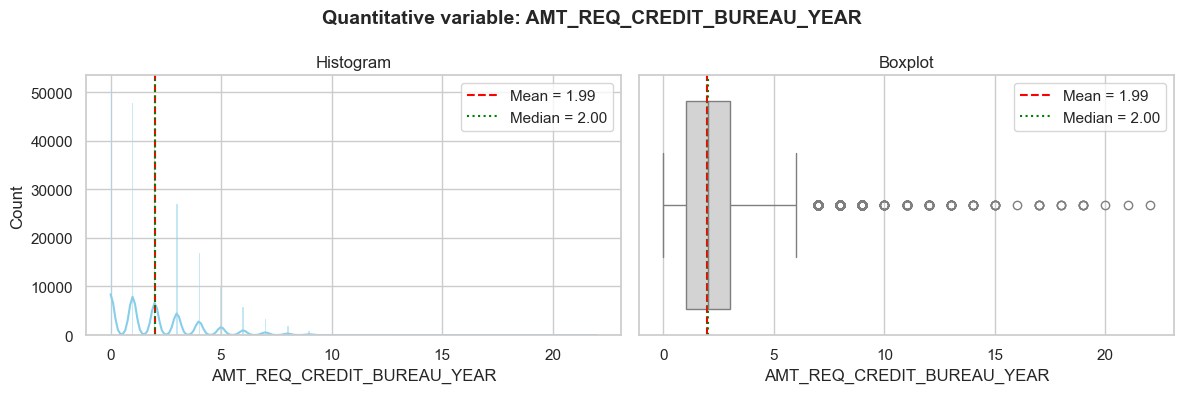

In [50]:
for col in credit_bureau_cols:
    plot_quantitative_distribution(df=app_df_3, target=col)